<a href="https://colab.research.google.com/github/AKChumba/NLP_LABS/blob/main/NAT820S_Lab_Weeks6_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NAT820S — Practical Lab: Clustering, Topic Modeling & Text Classification

**Weeks 6–7 | Natural Language Processing and Applications**

In this lab you'll get hands-on with everything from Lecture 4:
- Document clustering with K-Means
- Topic modeling with LDA
- Text classification with Naive Bayes, Logistic Regression & SVM
- Evaluating classifiers properly (not just accuracy!)

Look out for **🔧 TODO** cells — that's where you write code. Everything else is a worked example you can run and adapt.

> Reference: Gupta, Majumder & Vajjala (2020), *Practical Natural Language Processing*, O'Reilly, Chapters 4 & 7.

**How to use this notebook:** Run each cell in order (Shift+Enter). Read the markdown before each code cell — it tells you what the code does and what you need to do next.

## Part 0 — Setup

In [ ]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

!pip install gensim -q
import gensim
from gensim import corpora
from gensim.models import LdaModel

print("Setup complete ✅ (gensim version:", gensim.__version__, ")")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 33.1 MB/s eta 0:00:00
Setup complete ✅ (gensim version: 4.4.0 )


## Part 1 — Document Clustering with K-Means

We'll use a small collection of documents from a few different topics, turn them into TF-IDF vectors, then let K-Means group them automatically — with no labels given.

In [ ]:
documents = [
    "The dog wagged its tail and barked happily at its owner.",
    "My cat loves to sleep on the warm windowsill all afternoon.",
    "Puppies and kittens are adorable furry pets to cuddle at home.",
    "The stock market rallied sharply after the interest rate announcement.",
    "Investors are worried about inflation and rising bond market yields.",
    "The central bank raised interest rates again to control inflation.",
    "The striker scored a hat-trick in last night's football match.",
    "The football team's defense was rock solid throughout the game.",
    "Football fans celebrated wildly after the winning goal in extra time.",
]

tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(documents)
print("Feature matrix shape:", X.shape)
print("Vocabulary sample:", list(tfidf.vocabulary_.keys())[:10])

Feature matrix shape: (9, 55)
Vocabulary sample: ['dog', 'wagged', 'tail', 'barked', 'happily', 'owner', 'cat', 'loves', 'sleep', 'warm']


In [ ]:
# Cluster into 3 groups (we picked k=3 because we can see 3 topics: pets, finance, football)
kmeans = KMeans(n_clusters=3, random_state=1, n_init=10)
kmeans.fit(X)

for doc, label in zip(documents, kmeans.labels_):
    print(f"Cluster {label}: {doc}")

Cluster 0: The dog wagged its tail and barked happily at its owner.
Cluster 0: My cat loves to sleep on the warm windowsill all afternoon.
Cluster 0: Puppies and kittens are adorable furry pets to cuddle at home.
Cluster 1: The stock market rallied sharply after the interest rate announcement.
Cluster 1: Investors are worried about inflation and rising bond market yields.
Cluster 1: The central bank raised interest rates again to control inflation.
Cluster 2: The striker scored a hat-trick in last night's football match.
Cluster 2: The football team's defense was rock solid throughout the game.
Cluster 2: Football fans celebrated wildly after the winning goal in extra time.


### 🔧 TODO 1.1
Add **three more sentences** of your own — pick one topic already above (pets, finance, or football) and write one new sentence for it, plus two sentences on a **brand new topic** of your choice (e.g. cooking, weather). Re-run clustering with `n_clusters=4`. Do your new sentences land in sensible clusters?

In [ ]:
# TODO: create `my_documents` = documents + your 3 new sentences,
# refit TfidfVectorizer and KMeans(n_clusters=4) on my_documents, and print the cluster assignments
my_documents = documents.copy()
# my_documents.append("...")
# my_documents.append("...")
# my_documents.append("...")


### 🔧 TODO 1.2 — Reflection
K-Means needs you to *choose* k (the number of clusters) in advance. How did you decide k=4 was right for your data? What might go wrong if you picked k=2 instead?

**Your answer here:**


## Part 2 — Topic Modeling with LDA

Now let's discover topics **without** deciding the number of clusters by hand in quite the same way — LDA gives us a probability distribution over topics for every document, and a probability distribution over words for every topic. We'll use the same toy corpus from the lecture.

In [ ]:
lecture_corpus = [
    "I like to eat broccoli and bananas",
    "I ate a banana and salad for breakfast",
    "Puppies and kittens are cute",
    "My sister adopted a kitten yesterday",
    "Look at this cute hamster munching on a piece of broccoli",
]

# Tokenize and remove stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

texts = [
    [w.lower() for w in nltk.word_tokenize(doc) if w.isalpha() and w.lower() not in stop_words]
    for doc in lecture_corpus
]
print(texts)

[['like', 'eat', 'broccoli', 'bananas'], ['ate', 'banana', 'salad', 'breakfast'], ['puppies', 'kittens', 'cute'], ['sister', 'adopted', 'kitten', 'yesterday'], ['look', 'cute', 'hamster', 'munching', 'piece', 'broccoli']]


In [ ]:
# Build a gensim dictionary and bag-of-words corpus
dictionary = corpora.Dictionary(texts)
bow_corpus = [dictionary.doc2bow(text) for text in texts]

# Train an LDA model looking for 2 topics (we expect: food, and pets)
lda_model = LdaModel(bow_corpus, num_topics=2, id2word=dictionary, passes=50, random_state=42)

for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.070*"kitten" + 0.070*"adopted" + 0.070*"sister" + 0.070*"yesterday" + 0.070*"ate" + 0.070*"banana" + 0.070*"salad" + 0.070*"breakfast" + 0.070*"like" + 0.070*"bananas"
Topic 1: 0.134*"cute" + 0.083*"broccoli" + 0.081*"hamster" + 0.081*"look" + 0.081*"munching" + 0.081*"piece" + 0.080*"kittens" + 0.080*"puppies" + 0.027*"eat" + 0.027*"bananas"


### 🔧 TODO 2.1
For each document in `lecture_corpus`, print its topic distribution using `lda_model.get_document_topics(bow_corpus[i])`. Do documents 1–2 lean toward one topic, and documents 3–4 toward the other, like in the lecture?

In [ ]:
# TODO: loop over bow_corpus and print lda_model.get_document_topics(doc) for each,
# alongside the original sentence for reference


### 🔧 TODO 2.2 — Reflection
Look at the top words LDA found for each topic. Would you label them "food" and "pets" like in the lecture? Are there any surprising or noisy words in either topic? What could you do to clean the corpus and get better topics?

**Your answer here:**


## Part 3 — Text Classification: Building the Pipeline

Now let's build actual classifiers. We'll use scikit-learn's built-in 20 Newsgroups dataset (a real, well-known text classification benchmark) so we have enough data for meaningful results, restricted to 2 categories to keep things fast and simple to interpret.

In [ ]:
from sklearn.datasets import fetch_20newsgroups

categories = ["rec.sport.hockey", "sci.space"]
train_data = fetch_20newsgroups(subset="train", categories=categories, remove=("headers", "footers", "quotes"))
test_data = fetch_20newsgroups(subset="test", categories=categories, remove=("headers", "footers", "quotes"))

print("Training examples:", len(train_data.data))
print("Test examples:", len(test_data.data))
print("Classes:", train_data.target_names)
print()
print("Example document:")
print(train_data.data[0][:300])
print("Label:", train_data.target_names[train_data.target[0]])

Training examples: 1193
Test examples: 793
Classes: ['rec.sport.hockey', 'sci.space']

Example document:
Individual leaders by total points (Final standings)
    NOTE: Games played and points per games not accurate !!

    Player       Team   GP  G   A  Pts ppg  Prj PIM +/-

    M.Lemieux    PIT    59  69  91 160 2.71 160  38  53
    LaFontaine   BUF    82  53  95 148 1.80 148  63  13
    Oates        
Label: rec.sport.hockey


### Step 1–2: already done above (train/test split is built into the dataset loader).

### Step 3: Transform text into feature vectors

In [ ]:
vect = CountVectorizer(stop_words="english", max_features=5000)
X_train_dtm = vect.fit_transform(train_data.data)
X_test_dtm = vect.transform(test_data.data)

print("Training feature matrix shape:", X_train_dtm.shape)
print("Test feature matrix shape:", X_test_dtm.shape)

Training feature matrix shape: (1193, 5000)
Test feature matrix shape: (793, 5000)


### 🔧 TODO 3.1
Check the class balance: how many training examples belong to each of the two categories? (Hint: use `np.bincount(train_data.target)`.) Is this dataset balanced or imbalanced, unlike the book's news-relevance example?

In [ ]:
# TODO: use np.bincount on train_data.target and print the counts per class


## Part 4 — Naive Bayes Classifier

### Step 4–5: Train and evaluate

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_dtm, train_data.target)
y_pred_nb = nb.predict(X_test_dtm)

print("Naive Bayes accuracy:", metrics.accuracy_score(test_data.target, y_pred_nb))
print()
print(classification_report(test_data.target, y_pred_nb, target_names=train_data.target_names))

Naive Bayes accuracy: 0.935687263556116

                  precision    recall  f1-score   support

rec.sport.hockey       0.94      0.93      0.94       399
       sci.space       0.93      0.94      0.94       394

        accuracy                           0.94       793
       macro avg       0.94      0.94      0.94       793
    weighted avg       0.94      0.94      0.94       793



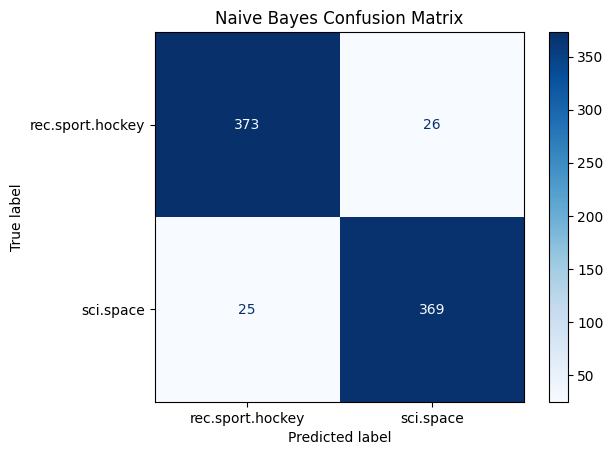

In [ ]:
cm = confusion_matrix(test_data.target, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.target_names)
disp.plot(cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

### 🔧 TODO 4.1
Naive Bayes needs a `MultinomialNB()` instance. Try `max_features=1000` instead of `5000` in the `CountVectorizer` from Part 3, retrain, and compare accuracy. Does fewer features help or hurt here? (Recall the book's Reason 1: too many features can add noise.)

In [ ]:
# TODO: create a new CountVectorizer with max_features=1000, refit, retrain a fresh
# MultinomialNB(), and print its accuracy on the test set


## Part 5 — Logistic Regression

In [ ]:
logreg = LogisticRegression(class_weight="balanced", max_iter=1000)
logreg.fit(X_train_dtm, train_data.target)
y_pred_lr = logreg.predict(X_test_dtm)

print("Logistic Regression accuracy:", metrics.accuracy_score(test_data.target, y_pred_lr))
print()
print(classification_report(test_data.target, y_pred_lr, target_names=train_data.target_names))

Logistic Regression accuracy: 0.9255989911727617

                  precision    recall  f1-score   support

rec.sport.hockey       0.91      0.94      0.93       399
       sci.space       0.94      0.91      0.92       394

        accuracy                           0.93       793
       macro avg       0.93      0.93      0.93       793
    weighted avg       0.93      0.93      0.93       793



### 🔧 TODO 5.1
Retrain logistic regression **without** `class_weight="balanced"` (just `LogisticRegression(max_iter=1000)`). Does accuracy change much? Would you expect a bigger difference on an imbalanced dataset like the book's news-relevance example?

In [ ]:
# TODO: train a LogisticRegression without class_weight="balanced" and compare accuracy


## Part 6 — Support Vector Machine

In [ ]:
svm_clf = LinearSVC(class_weight="balanced", max_iter=5000)
svm_clf.fit(X_train_dtm, train_data.target)
y_pred_svm = svm_clf.predict(X_test_dtm)

print("SVM accuracy:", metrics.accuracy_score(test_data.target, y_pred_svm))
print()
print(classification_report(test_data.target, y_pred_svm, target_names=train_data.target_names))

SVM accuracy: 0.8953341740226987

                  precision    recall  f1-score   support

rec.sport.hockey       0.86      0.95      0.90       399
       sci.space       0.94      0.84      0.89       394

        accuracy                           0.90       793
       macro avg       0.90      0.90      0.89       793
    weighted avg       0.90      0.90      0.90       793



## Part 7 — Comparing the Three Classifiers

### 🔧 TODO 7.1
Build a small `pandas` DataFrame comparing Naive Bayes, Logistic Regression and SVM on this dataset: columns `Classifier`, `Accuracy`, `F1 (macro)`. Use `metrics.f1_score(y_true, y_pred, average="macro")` for the F1 column.

In [ ]:
# TODO: compute accuracy and macro F1 for each of y_pred_nb, y_pred_lr, y_pred_svm,
# then build and display a comparison DataFrame

results = [
    # {"Classifier": "Naive Bayes", "Accuracy": ..., "F1 (macro)": ...},
    # {"Classifier": "Logistic Regression", "Accuracy": ..., "F1 (macro)": ...},
    # {"Classifier": "SVM", "Accuracy": ..., "F1 (macro)": ...},
]

pd.DataFrame(results)

""


### 🔧 TODO 7.2 — Try Your Own Text
Write **two sentences of your own** — one that sounds like it's about hockey, one that sounds like it's about space — and use your best classifier to predict their category. Did it get both right?

Hint: `vect.transform([your_sentence])` then `.predict(...)` on that transformed vector, using whichever `vect` (5000 or 1000 features) matches the classifier you're using.

In [ ]:
# TODO: write two sentences, transform them with `vect`, and predict with your best classifier
my_sentences = [
    "",  # your hockey-themed sentence
    "",  # your space-themed sentence
]


## Part 8 — Wrap-Up

### Reflection

In 3–4 sentences: based on everything in this lab, when would you reach for **clustering** versus **classification** in a real project? Give one concrete example of each from your own interests (e.g. news app, e-commerce site, student portal).

**Your answer here:**

---
*End of lab. Save your notebook (File → Save a copy in Drive) before you leave.*